<a href="https://colab.research.google.com/github/morenakukurin/Repo_AIbio/blob/4.-vela/Copy_of_UniRi_Ch06_ML_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('https://github.com/bio-chem-info/python_course/raw/refs/heads/main/classification_data.csv')
dataset
#sample code number nije prediktor

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
678,776715,3,1,1,1,3,2,1,1,1,2
679,841769,2,1,1,1,2,1,1,1,1,2
680,888820,5,10,10,3,7,3,8,10,2,4
681,897471,4,8,6,4,3,4,10,6,1,4


In [3]:
dataset = pd.read_csv('https://github.com/bio-chem-info/python_course/raw/refs/heads/main/classification_data.csv',
                      index_col=0). #prvi stupac je indexni stupac, odnosno ID
dataset

#outcome da li je tumor benigan ili maligni

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
Sample code number,,,,,,,,,,
1000025,5,1,1,1,2,1,3,1,1,2
1002945,5,4,4,5,7,10,3,2,1,2
1015425,3,1,1,1,2,2,3,1,1,2
1016277,6,8,8,1,3,4,3,7,1,2
1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
776715,3,1,1,1,3,2,1,1,1,2
841769,2,1,1,1,2,1,1,1,1,2
888820,5,10,10,3,7,3,8,10,2,4


In [4]:
dataset.describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


<Axes: >

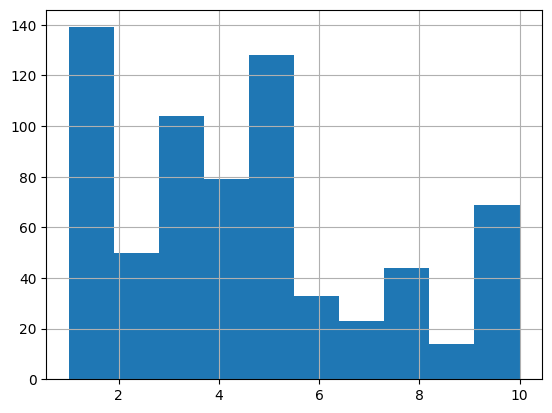

In [5]:
dataset['Clump Thickness'].hist()

In [6]:
dataset.groupby("Class").describe() #podijelimo data set prema nekoj varijabli u nekoliko grupa

Clump Thickness                                                 \
                count      mean       std  min  25%  50%   75%   max   
Class                                                                  
2               444.0  2.963964  1.672661  1.0  1.0  3.0   4.0   8.0   
4               239.0  7.188285  2.437907  1.0  5.0  8.0  10.0  10.0   

      Uniformity of Cell Size            ... Normal Nucleoli       Mitoses  \
                        count      mean  ...             75%   max   count   
Class                                    ...                                 
2                       444.0  1.306306  ...             1.0   8.0   444.0   
4                       239.0  6.577406  ...             9.5  10.0   239.0   

                                                     
           mean       std  min  25%  50%  75%   max  
Class                                                
2      1.065315  0.509738  1.0  1.0  1.0  1.0   8.0  
4      2.602510  2.564495  1.0  1.0  1.0  3.0  10.0  

[2 rows x 72 columns]

koji je outcome?


In [7]:
!pip install pingouin
import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.4 MB/s eta 0:00:00


<Axes: >

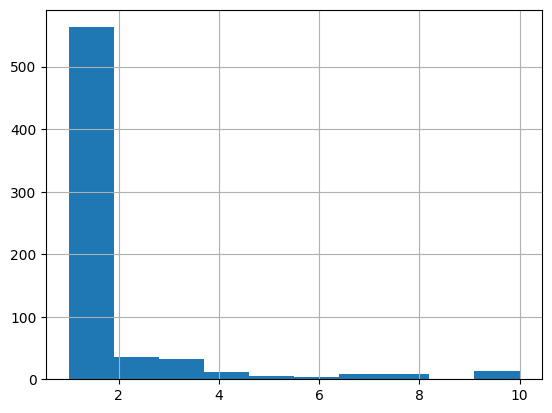

In [9]:
dataset['Mitoses'].hist()

In [8]:
pg.mwu(dataset[dataset.Class==2]['Mitoses'],
       dataset[dataset.Class==4]['Mitoses']) #man whitney u test, za usporedbu dva uzorka, neparametrijska inacica

,U-val,alternative,p-val,RBC,CLES
MWU,30599.0,two-sided,3.743169e-43,-0.423291,0.288354


postoji razlika izm benignog i malignog



---

`Explore the data!`

---



In [10]:
dataset['Class'].value_counts()

,count
Class,
2,444
4,239




---
`Lets get some statistics done here!`


---




In [11]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]
X.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
Sample code number,,,,,,,,,
1000025,5,1,1,1,2,1,3,1,1
1002945,5,4,4,5,7,10,3,2,1
1015425,3,1,1,1,2,2,3,1,1
1016277,6,8,8,1,3,4,3,7,1
1017023,4,1,1,3,2,1,3,1,1


In [12]:
y

,Class
Sample code number,
1000025,2
1002945,2
1015425,2
1016277,2
1017023,2
...,...
776715,2
841769,2
888820,4


## Splitting the dataset into the Training set and Test set

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)
X_train.shape, X_test.shape

((512, 9), (171, 9))

## Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [19]:
pd.DataFrame(X_test, columns = X.columns).describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
count,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000
mean,4.497076,3.210526,3.309942,2.900585,3.239766,3.795322,3.403509,2.684211,1.678363
std,2.872536,3.110155,3.093231,2.939898,2.124326,3.719453,2.325255,2.858370,1.787719
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,3.500000,4.000000,8.000000,5.000000,3.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


## Training the Logistic Regression model on the Training set

In [20]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0, penalty="elasticnet",
                                solver="saga", l1_ratio=0.9)
classifier.fit(X_train, y_train) #parametrizira odnos dijagnoze spram ovih featurea koje smo izmjerili

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(l1_ratio=0.9, penalty='elasticnet', random_state=0,
                   solver='saga')

In [21]:
pd.DataFrame(X_train, columns=X.columns)

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
Sample code number,,,,,,,,,
142932,7,6,10,5,3,10,9,10,2
1120559,8,3,8,3,4,9,8,9,8
1254538,8,10,10,10,6,10,10,10,1
688033,1,1,1,1,2,1,1,1,1
428598,1,1,3,1,1,1,2,1,1
...,...,...,...,...,...,...,...,...,...
1033078,4,2,1,1,2,1,2,1,1
521441,5,1,1,2,2,1,2,1,1
1214092,1,1,1,1,2,1,1,1,1


In [23]:
pd.Series(np.squeeze(classifier.coef_), index = X.columns)

,0
Clump Thickness,0.078991
Uniformity of Cell Size,0.399628
Uniformity of Cell Shape,0.148749
Marginal Adhesion,0.089458
Single Epithelial Cell Size,-0.016036
Bare Nuclei,0.398175
Bland Chromatin,0.000688
Normal Nucleoli,0.232405
Mitoses,0.000000


<Axes: >

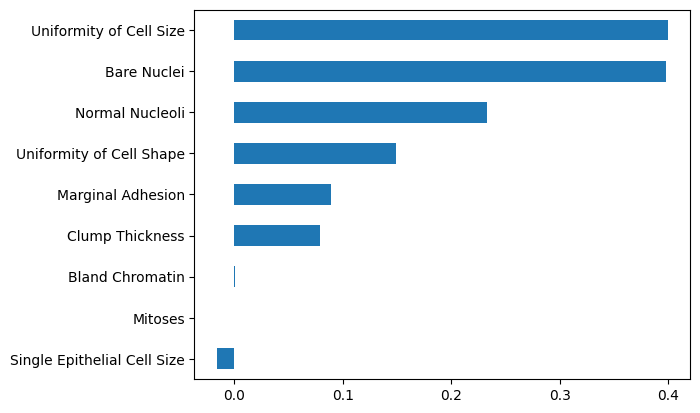

In [24]:

pd.Series(np.squeeze(classifier.coef_), name="coefs", index=X.columns).sort_values().plot.barh()

## Making the Confusion Matrix

In [25]:
y_pred = classifier.predict(X_test)
y_pred

array([2, 2, 4, 4, 2, 2, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 4, 4, 2, 2, 2,
       4, 2, 4, 4, 2, 2, 2, 4, 2, 4, 4, 2, 2, 2, 4, 4, 2, 4, 2, 2, 2, 2,
       2, 2, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 4, 2, 4, 2, 2, 2, 2, 2, 2,
       2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 4, 2, 4, 2, 2, 4, 2, 4,
       4, 2, 4, 2, 4, 2, 2, 4, 4, 4, 2, 2, 2, 2, 4, 4, 2, 2, 4, 2, 2, 2,
       4, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 4, 4, 2, 4, 2, 4, 2, 2,
       4, 2, 2, 4, 2, 4, 2, 2, 2, 2, 2, 2, 2, 4, 4, 2, 4, 2, 4, 2, 2, 2,
       2, 2, 4, 4, 2, 4, 4, 4, 4, 2, 4, 2, 2, 2, 2, 2, 2])

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [27]:
y_pred = pd.Series(y_pred, name='Pred', index=y_test.index)
y_pred

,Pred
Sample code number,
1173347,2
1156017,2
706426,4
1330439,4
693702,2
...,...
1266124,2
1197979,2
764974,2


In [28]:
results = pd.concat([y_test, y_pred], axis=1)
results

,Class,Pred
Sample code number,,
1173347,2,2
1156017,2,2
706426,4,4
1330439,4,4
693702,2,2
...,...,...
1266124,2,2
1197979,2,2
764974,2,2


In [29]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[103   4]
 [  8  56]]


In [30]:
accuracy_score(y_test, y_pred)*100

92.98245614035088